In [40]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot

import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()

wr40_n300_mm = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023/sig/WR4000N300MM.root"
file1 = uproot.open(wr40_n300_mm)
events = file1["Central"]
lhe_pt = events["Cutflow_for_Boosted_SR"].values()

wr40_n300_ee = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023/sig/WR4000N300EE.root"
file2 = uproot.open(wr40_n300_ee)
events2 = file2["Central"]
lhe_pt2 = events2["Cutflow_for_Boosted_SR"].values()



wr40_n2100_mm = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023/sig/WR4000N2100MM.root"
file3 = uproot.open(wr40_n2100_mm)
events3 = file3["Central"]
lhe_pt3 = events3["Cutflow_for_reseolved_SR"].values()


wr40_n2100_ee = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023/sig/WR4000N2100EE.root"
file4 = uproot.open(wr40_n2100_ee)
events4 = file4["Central"]
lhe_pt4 = events4["Cutflow_for_reseolved_SR"].values()


In [41]:
print(lhe_pt)
print(lhe_pt2)
print(lhe_pt3)
print(lhe_pt4)

[0.00000000e+00 3.33281604e+01 3.33281604e+01 2.48194810e+01
 2.37315546e+01 2.30659437e+01 2.30330916e+01 1.08240342e+01
 1.07492839e+01 9.90560537e+00 9.84466245e+00 9.84466245e+00
 2.06400000e+04]
[ 0.         33.32816035 33.32816035 27.1829237  22.65600729 22.61744185
 22.60363447 12.69802909 12.6494652   8.69912597  8.49963312  8.49963312
  8.46535273]
[ 0.         15.45230953 15.45230953 12.12129898 12.03550407 11.28618237
 11.24466871 11.24466871 11.24466871 10.95476493]
[ 0.         15.45230902 15.45230902  9.02481071  9.01576007  8.47051431
  8.44888108  8.44888108  8.44888108  8.19678769]


In [45]:
# ── 각 컷의 설명을 여기에 채워주세요 ──────────────────────────────────────────

boosted_labels = [
    "All",   # 설명
    "Noise filter",   # 설명
    "Not resolved",   
    "Tight lepton $\geq 1$ ,  $p_T$ , $\eta$ , id ",  # 설명
    "Trigger",   # 설명1
    " $\Delta \phi (lep , Fatjet) < 2.0$",
    "No extra tight lep",   # 설명
    "$l_{loose,SF}$ in Jet",   # 설명
    "$No l_{loose,OF}$ in Jet",   # 설명
    "$M_{ll}$>200 GeV",   # 설명
    "$W_{R}$>800 GeV",  # 설명
]

resolved_labels = [
    "All",   # 설명
    "Noise filter",   # 설명
    "$N_{lep_{tight}} == 2$ , $p_T$ , $\eta$ , id ",  # 설명
    "Trigger",   # 설명
    "$N_{jet} \geq 2$ , $p_T$ , $\eta$ , id",   # 설명
    "All object resolved",   # 설명
    "$W_{R}$>800 GeV , $M_{ll}$>200 GeV",   # 설명
]


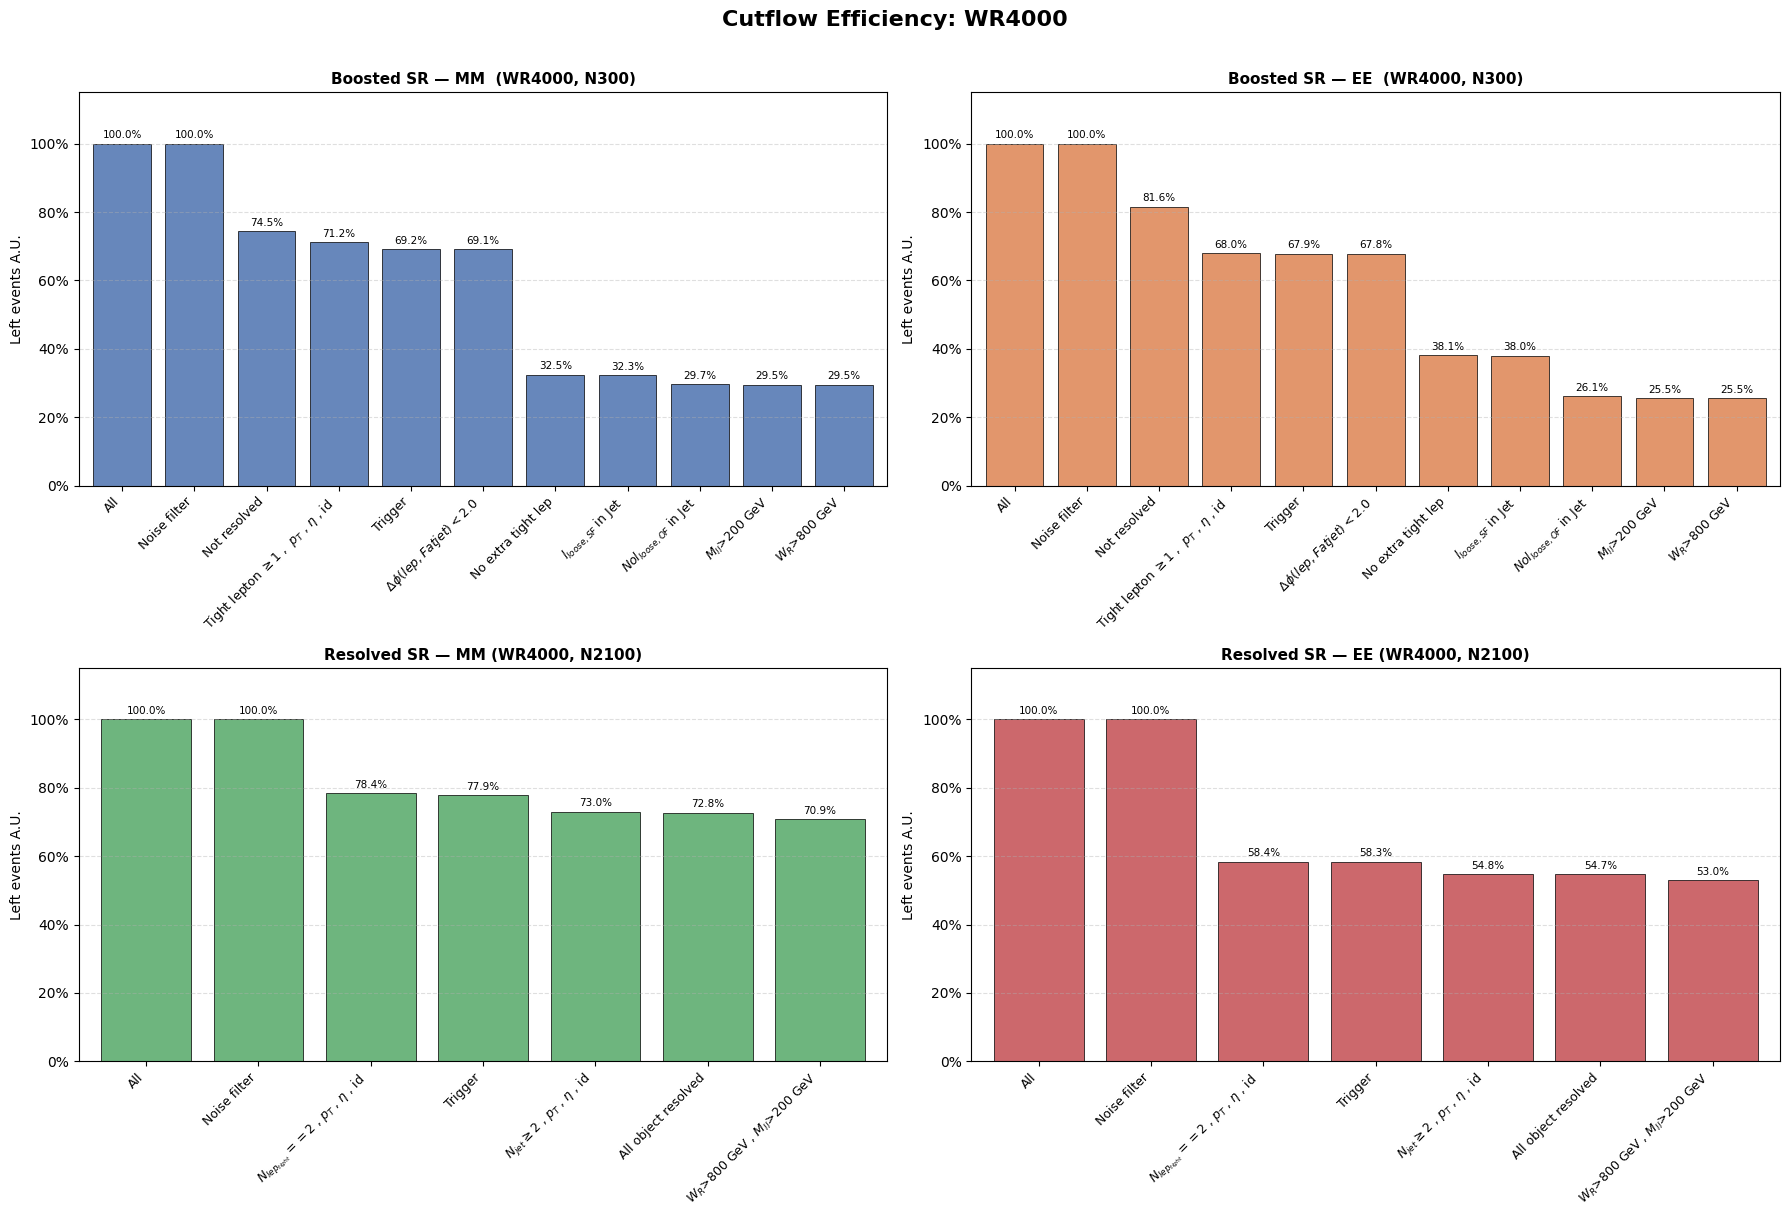

Saved: cutflow_4panels.png


In [48]:
def to_ratio(values):
    base = values[0]
    return np.array(values) / base

# resolved: index 0~5 (Cut1~6) + index 8 (Cut9), skip 6,7 (Cut7,8)
resolved_idx = [0, 1, 2, 3, 4, 5, 8]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Cutflow Efficiency: WR4000", fontsize=16, fontweight="bold", y=1.01)

plot_configs = [
    (axes[0, 0], to_ratio(lhe_pt[1:12]),                      boosted_labels,  "Boosted SR — MM  (WR4000, N300)"),
    (axes[0, 1], to_ratio(lhe_pt2[1:12]),                     boosted_labels,  "Boosted SR — EE  (WR4000, N300)"),
    (axes[1, 0], to_ratio(lhe_pt3[1:][resolved_idx]),         resolved_labels, "Resolved SR — MM (WR4000, N2100)"),
    (axes[1, 1], to_ratio(lhe_pt4[1:][resolved_idx]),         resolved_labels, "Resolved SR — EE (WR4000, N2100)"),
]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for (ax, ratios, labels, title), color in zip(plot_configs, colors):
    x = np.arange(len(labels))
    bars = ax.bar(x, ratios, color=color, edgecolor="black", linewidth=0.6, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Left events A.U.", fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_xlim(-0.6, len(labels) - 0.4)

    for bar, val in zip(bars, ratios):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.1%}",
            ha="center", va="bottom", fontsize=7.5,
        )

plt.tight_layout()
plt.savefig("cutflow_4panels.png", dpi=500, bbox_inches="tight")
plt.show()
print("Saved: cutflow_4panels.png")
